<a href="https://colab.research.google.com/github/Jeffrey-AI-research/Stock-Market-Predictions-AI-Research/blob/main/Stock_Market_Predictions_AI_Research_(LR_Revision_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")

In [2]:
# Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


In [3]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Ticker,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6290 non-null   datetime64[ns]
 1   Open       6290 non-null   float64       
 2   High       6290 non-null   float64       
 3   Low        6290 non-null   float64       
 4   Close      6290 non-null   float64       
 5   Adj Close  6290 non-null   float64       
 6   Volume     6290 non-null   int64         
 7   Ticker     6290 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 393.3+ KB


In [6]:
# exploratory data analysis
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,6290,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,2021-06-30 18:48:38.918919168,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
min,2019-01-02 00:00:00,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,2020-04-01 00:00:00,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,2021-06-30 12:00:00,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,2022-09-29 00:00:00,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,2023-12-29 00:00:00,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08
std,NaN,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07


In [7]:
df["Ticker"].value_counts()

,count
Ticker,
AAPL,1258
MSFT,1258
AMZN,1258
GOOGL,1258
TSLA,1258


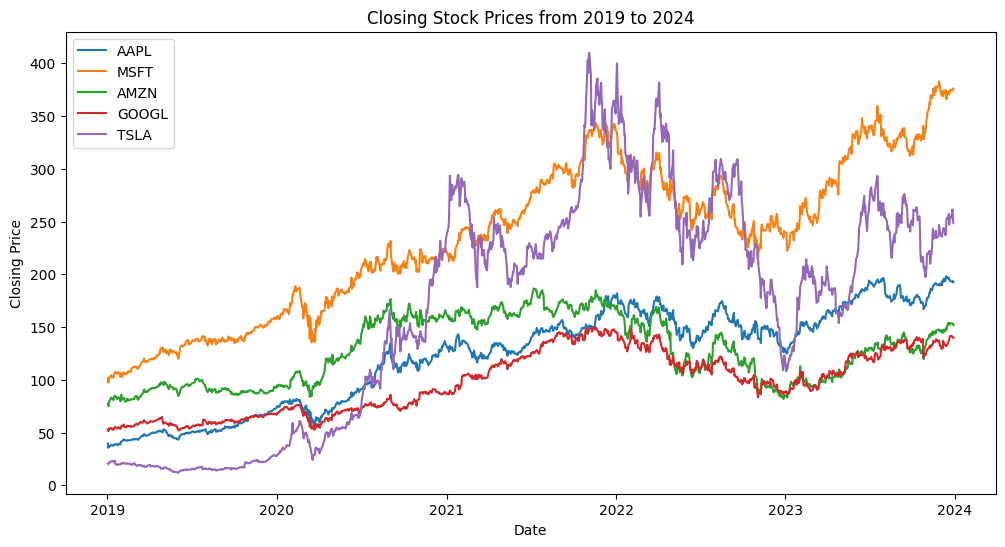

In [8]:
# exploratory data analysis - Closing Stock prices
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6)) # Make new graph(12in x 6in)
for ticker in df["Ticker"].unique(): # For each ticker, filter data table
    stock = df[df["Ticker"] == ticker]
    plt.plot(stock["Date"], stock["Close"], label=ticker)

plt.title("Closing Stock Prices from 2019 to 2024")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend() # Creates the reference(top left)

plt.savefig("closing_prices.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()

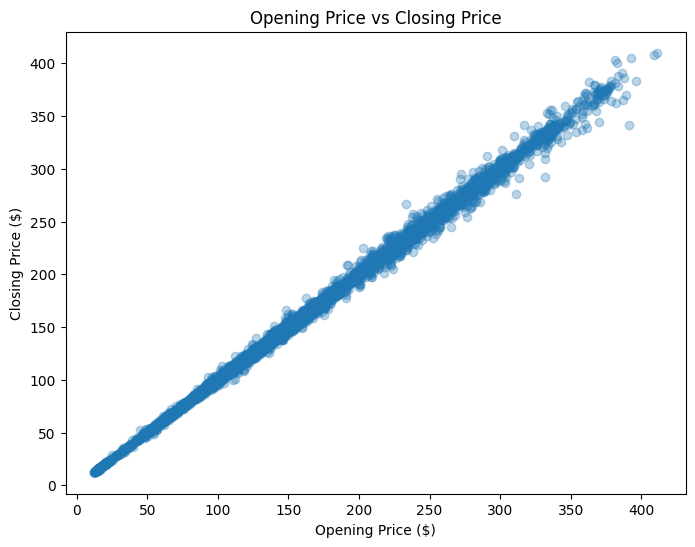

In [9]:
# exploratory data analysis - Open Price vs Closing Price

# Figure 1: Open Price vs Closing Price
plt.figure(figsize=(8,6)) # Make new graph(8in x 6in)
plt.scatter(df["Open"], df["Close"], alpha=0.3) # alpha: transparency

plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price ($)")
plt.ylabel("Closing Price ($)")

plt.savefig("open_vs_close.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()


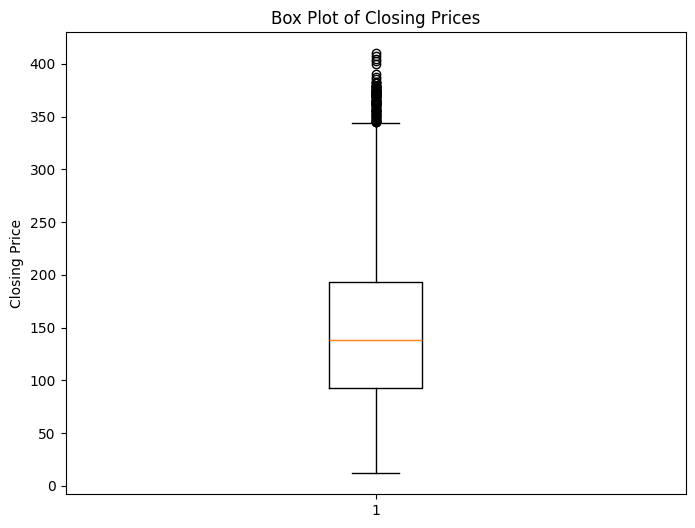

In [10]:
# exploratory data analysis - Potential Issues for Closing Prices
plt.figure(figsize=(8,6)) # Make new graph(8in x 6in)
plt.boxplot(df["Close"])

plt.title("Box Plot of Closing Prices")
plt.ylabel("Closing Price")

plt.savefig("closing_price_boxplot.png", dpi=300, bbox_inches="tight") # Saves visualization/graph
plt.show()
# The points above the range are "outliers" and are each explicitly shown; other points are "normal" and not explicitly shown.

In [11]:
# Training Machine Learning Model (Linear Regression)

In [12]:
df["Target"] = df.groupby("Ticker")["Close"].shift(-1) # Create the target variable

df = df.dropna() # Remove rows with missing target values

In [13]:
df = df.sort_values("Date") # Sort the data by date
df["Previous_Close"] = df.groupby("Ticker")["Close"].shift(1)
df["Previous_Open"] = df.groupby("Ticker")["Open"].shift(1)
df = df.dropna()

In [14]:
X = df[["Open", "High", "Low", "Close", "Volume", "Previous_Open", "Previous_Close"]]
y = df["Target"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Create and train the model
model.fit(X_train, y_train)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

          Feature   Coefficient
0            Open -1.550450e-01
1            High  1.522229e-01
2             Low  2.064478e-01
3           Close  7.652549e-01
4          Volume  7.199999e-10
5   Previous_Open -4.120199e-02
6  Previous_Close  7.175662e-02


In [16]:
y_pred = model.predict(X_test) # Predict stock prices
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute Error"] = abs(results["Error"])

print(results.sort_values("Absolute Error", ascending=False).head(10))

          Actual   Predicted      Error  Absolute Error
6175  262.899994  291.747903 -28.847909       28.847909
6211  273.579987  249.454953  24.125033       24.125033
6239  220.110001  243.575143 -23.465142       23.465142
2343  295.369995  276.007427  19.362568       19.362568
6056  177.899994  159.285337  18.614657       18.614657
6203  257.179993  238.835488  18.344504       18.344504
6113  162.990005  180.875108 -17.885102       17.885102
6163  279.820007  261.984815  17.835192       17.835192
6158  241.050003  257.319029 -16.269026       16.269026
6055  160.270004  144.119372  16.150632       16.150632


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9970517445839147
Mean Absolute Error: 2.8516404094821204
Root Mean Squared Error: 4.242474419035115


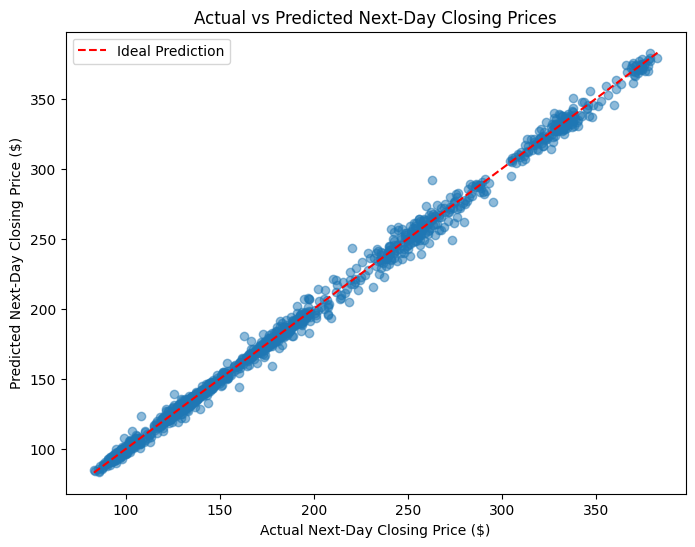

In [18]:
# Figure 2: Actual vs Predicted Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

minimum_price = min(y_test.min(), y_pred.min())
maximum_price = max(y_test.max(), y_pred.max())

plt.plot([minimum_price, maximum_price], [minimum_price, maximum_price],
         linestyle="--", color="red", label="Ideal Prediction")

plt.title("Actual vs Predicted Next-Day Closing Prices")
plt.xlabel("Actual Next-Day Closing Price ($)")
plt.ylabel("Predicted Next-Day Closing Price ($)")
plt.legend()

plt.savefig("figure2_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

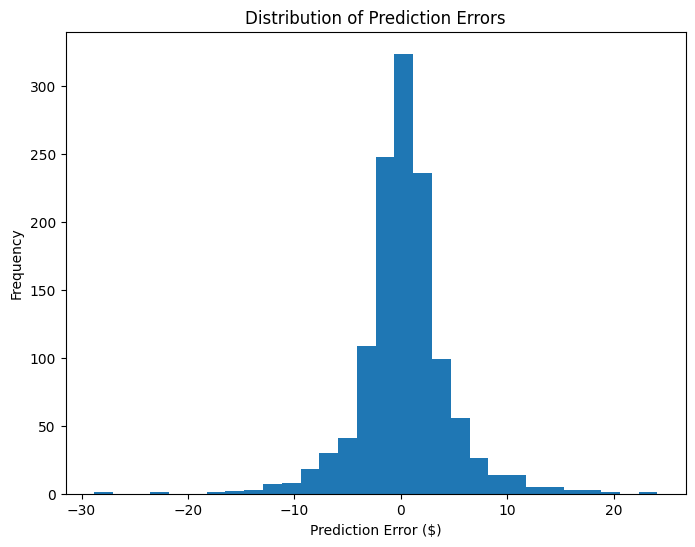

In [23]:
plt.figure(figsize=(8,6))
plt.hist(results["Error"], bins=30)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error ($)")
plt.ylabel("Frequency")

plt.savefig("error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

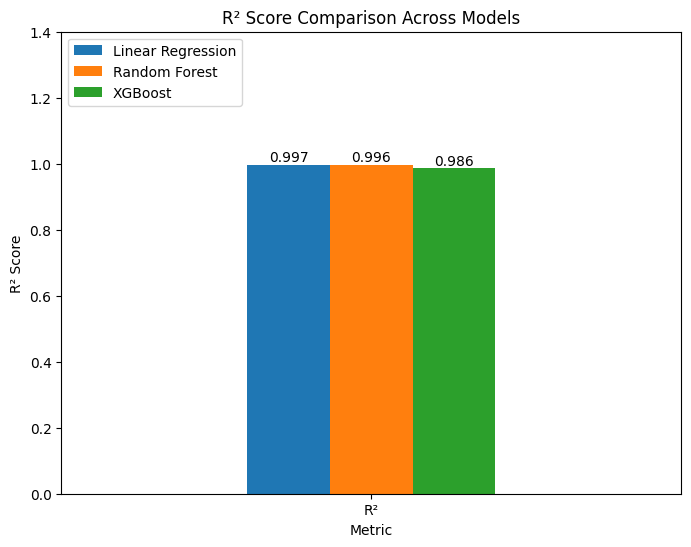

In [20]:
# Figure 3: R² Comparison

metrics = ["R²"]
linear = [r2_score(y_test, y_pred)]
random_forest = [0.99644733236667]
xgboost = [0.9863455642605348]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(8,6))

bars1 = plt.bar(x - width, linear, width, label="Linear Regression")
bars2 = plt.bar(x, random_forest, width, label="Random Forest")
bars3 = plt.bar(x + width, xgboost, width, label="XGBoost")

plt.title("R² Score Comparison Across Models")
plt.xlabel("Metric")
plt.ylabel("R² Score")
plt.xticks(x, metrics)
plt.xlim(-0.75, 0.75)
plt.ylim(0, 1.4)
plt.legend(loc="upper left")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}", ha="center")

plt.savefig("figure3_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

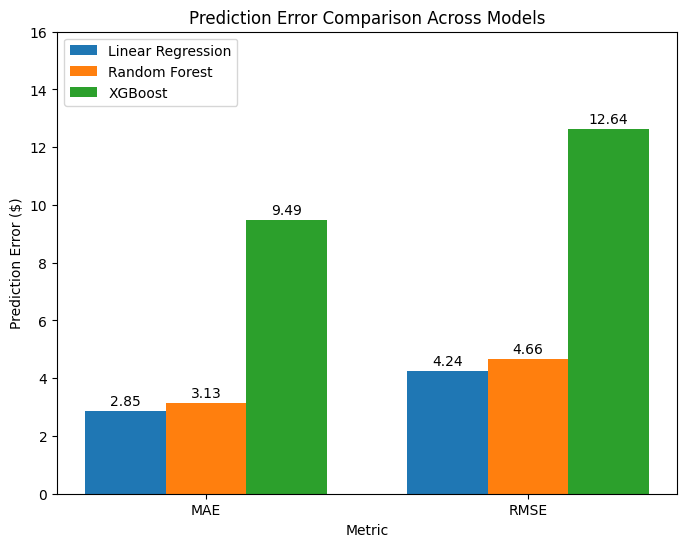

In [21]:
# Figure 4: MAE and RMSE Comparison

metrics = ["MAE", "RMSE"]
linear = [mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))]
random_forest = [3.1305537843499147, 4.658274316384531]
xgboost = [9.48813556865522, 12.64115302163617]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(8,6))

bars1 = plt.bar(x - width, linear, width, label="Linear Regression")
bars2 = plt.bar(x, random_forest, width, label="Random Forest")
bars3 = plt.bar(x + width, xgboost, width, label="XGBoost")

plt.title("Prediction Error Comparison Across Models")
plt.xlabel("Metric")
plt.ylabel("Prediction Error ($)")
plt.xticks(x, metrics)
plt.ylim(0, 16)
plt.legend(loc="upper left")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.2f}", ha="center")

plt.savefig("figure4_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()